In [1]:
import pandas as pd
import numpy as np


In [2]:
X_train = pd.read_csv("/app/data/X_train.csv")
y_train = pd.read_csv("/app/data/y_train.csv")

In [3]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (67532, 31)
y_train shape: (67532, 1)


In [4]:
X_train.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'item_count',
 'unique_products',
 'unique_sellers',
 'total_price',
 'total_freight',
 'payment_count',
 'total_payment',
 'payment_types',
 'review_count',
 'average_review_score',
 'product_count',
 'missing_product_category',
 'seller_count',
 'seller_states',
 'category_count',
 'geo_lat',
 'geo_lng',
 'geo_city_count',
 'geo_state_count']

In [5]:
missing = X_train.isna().sum().sort_values(ascending=False)

missing[missing > 0]

average_review_score            472
review_count                    472
geo_city_count                  175
geo_state_count                 175
geo_lat                         175
geo_lng                         175
order_approved_at                12
order_delivered_carrier_date      1
dtype: int64

In [6]:
numeric_cols = X_train.select_dtypes(include="number").columns

X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,67532.0,35218.778860,29829.706788,1003.000000,11360.000000,24445.000000,59070.250000,99980.000000
item_count,67532.0,1.141222,0.534073,1.000000,1.000000,1.000000,1.000000,20.000000
unique_products,67532.0,1.037952,0.227844,1.000000,1.000000,1.000000,1.000000,8.000000
unique_sellers,67532.0,1.013594,0.121902,1.000000,1.000000,1.000000,1.000000,5.000000
total_price,67532.0,137.704692,213.624439,0.850000,45.900000,86.990000,149.900000,13440.000000
total_freight,67532.0,22.867065,22.170292,0.000000,13.860000,17.190000,24.110000,1794.960000
payment_count,67532.0,1.043031,0.347376,1.000000,1.000000,1.000000,1.000000,22.000000
total_payment,67532.0,160.604042,223.606535,9.590000,62.010000,105.380000,176.630000,13664.080000
review_count,67060.0,1.005562,0.074972,1.000000,1.000000,1.000000,1.000000,3.000000
average_review_score,67060.0,4.157468,1.282651,1.000000,4.000000,5.000000,5.000000,5.000000


In [7]:
y_train["is_late"].value_counts()

is_late
0    62053
1     5479
Name: count, dtype: int64

In [10]:
y_train["is_late"].value_counts(normalize=True) * 100

is_late
0    91.886809
1     8.113191
Name: proportion, dtype: float64

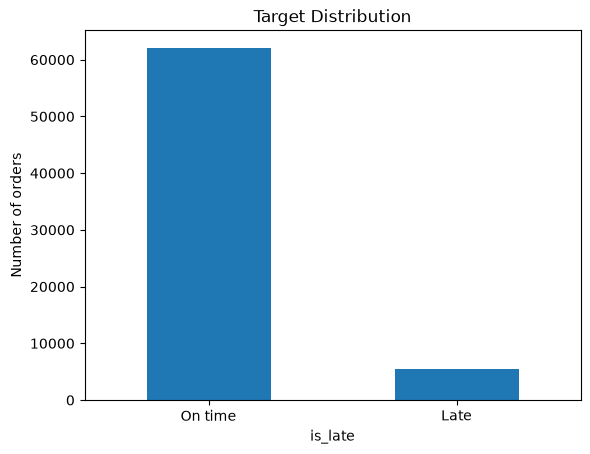

In [11]:
# Plot the target distribution to visualize the class imbalance
import matplotlib.pyplot as plt

y_train["is_late"].value_counts().sort_index().plot(
    kind="bar"
)

# Add clear labels and a title for the chart
plt.xlabel("is_late")
plt.ylabel("Number of orders")
plt.title("Target Distribution")
plt.xticks([0, 1], ["On time", "Late"], rotation=0)

plt.show()

In [12]:
# Calculate the number of missing values in each feature
missing_count = X_train.isna().sum()

# Calculate the percentage of missing values in each feature
missing_percent = (missing_count / len(X_train)) * 100

# Combine the counts and percentages into one table
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

# Show only features that contain missing values
missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
average_review_score,472,0.698928
review_count,472,0.698928
geo_lng,175,0.259136
geo_lat,175,0.259136
geo_city_count,175,0.259136
geo_state_count,175,0.259136
order_approved_at,12,0.017769
order_delivered_carrier_date,1,0.001481


In [13]:
# Compare key order features between on-time and late orders
eda_data = X_train.copy()

# Add the target only for EDA analysis; it will NOT be used as a model feature
eda_data["is_late"] = y_train["is_late"].values

# Compare the distributions of selected numeric features by delivery status
eda_data.groupby("is_late")[
    ["item_count", "total_price", "total_freight", "total_payment"]
].median()

,item_count,total_price,total_freight,total_payment
is_late,,,,
0,1.0,86.25,17.09,105.06
1,1.0,89.90,18.19,112.09


In [14]:
# Convert the purchase timestamp to datetime so we can analyze delivery patterns over time
eda_data = X_train.copy()
eda_data["order_purchase_timestamp"] = pd.to_datetime(
    eda_data["order_purchase_timestamp"]
)

# Add the target only for EDA analysis; it will not be used as a model feature
eda_data["is_late"] = y_train["is_late"].values

# Extract the purchase month from the order timestamp
eda_data["purchase_month"] = eda_data["order_purchase_timestamp"].dt.month

# Calculate the late-order rate for each purchase month
monthly_late_rate = (
    eda_data.groupby("purchase_month")["is_late"]
    .mean()
    .mul(100)
)

monthly_late_rate

purchase_month
1      6.333762
2     13.535388
3     17.090035
4      6.012907
5      6.800446
6      2.234206
7      4.085383
8      7.589104
9      5.798114
10     5.219207
11    14.114833
12     7.600102
Name: is_late, dtype: float64

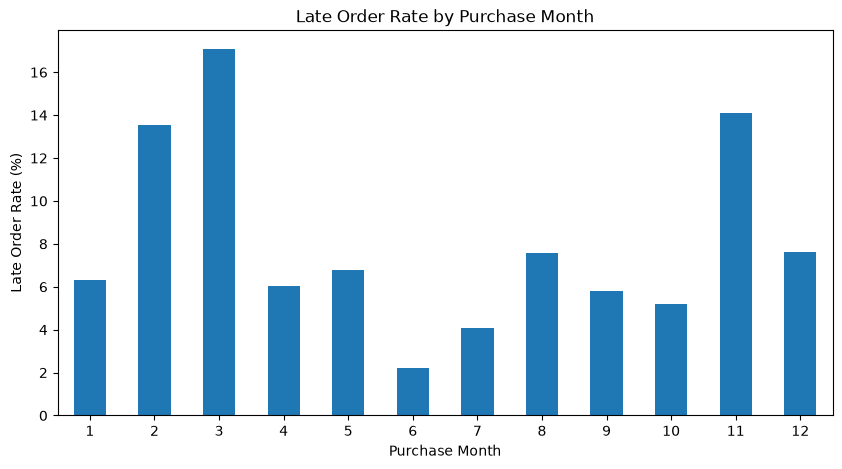

In [15]:
# Plot the late-order rate by purchase month to identify seasonal patterns
monthly_late_rate.plot(
    kind="bar",
    figsize=(10, 5)
)

# Add labels and title to clearly explain the analysis
plt.xlabel("Purchase Month")
plt.ylabel("Late Order Rate (%)")
plt.title("Late Order Rate by Purchase Month")
plt.xticks(rotation=0)

plt.show()

In [16]:
# Calculate the late-order rate for each customer state
state_late_rate = (
    eda_data.groupby("customer_state")["is_late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Display the states with the highest late-order rates
state_late_rate.head(10)

customer_state
AL    25.287356
MA    19.298246
RR    16.666667
PI    15.895954
CE    15.831435
SE    13.877551
RJ    13.717993
BA    13.539399
ES    12.491128
PA    12.406577
Name: is_late, dtype: float64

In [17]:
# Calculate both the number of orders and the late-order rate for each state
state_analysis = (
    eda_data.groupby("customer_state")["is_late"]
    .agg(
        order_count="count",
        late_rate="mean"
    )
)

# Convert the late rate from a proportion to a percentage
state_analysis["late_rate"] = state_analysis["late_rate"] * 100

# Sort states by late-order rate and display the highest rates
state_analysis.sort_values("late_rate", ascending=False).head(10)

,order_count,late_rate
customer_state,,
AL,261,25.287356
MA,513,19.298246
RR,30,16.666667
PI,346,15.895954
CE,878,15.831435
SE,245,13.877551
RJ,8631,13.717993
BA,2297,13.539399
ES,1409,12.491128


In [18]:
# Keep only states with enough orders to make the late-rate comparison more reliable
state_analysis_filtered = state_analysis[
    state_analysis["order_count"] >= 500
]

# Sort the filtered states by late-order rate
state_analysis_filtered.sort_values(
    "late_rate",
    ascending=False
).head(10)

,order_count,late_rate
customer_state,,
MA,513,19.298246
CE,878,15.831435
RJ,8631,13.717993
BA,2297,13.539399
ES,1409,12.491128
PA,669,12.406577
PE,1098,11.020036
SC,2460,9.878049
GO,1379,8.121827


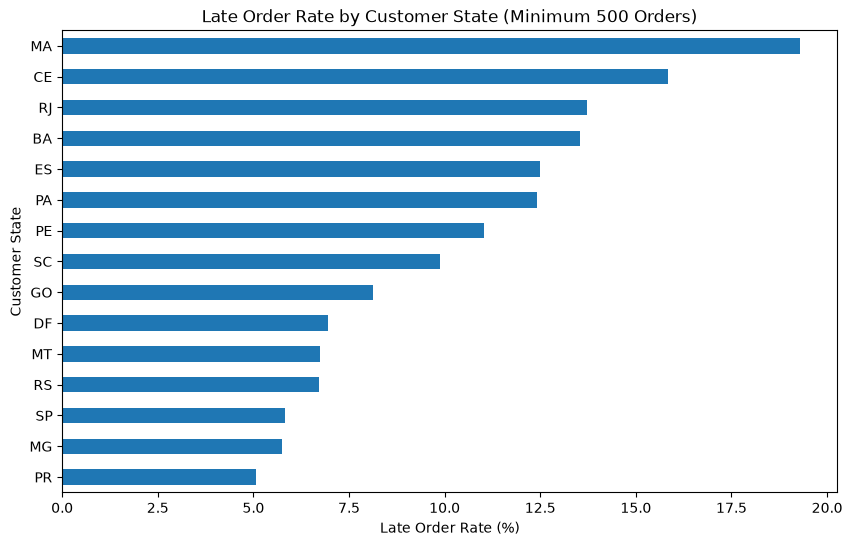

In [19]:
# Plot late-order rates for states with at least 500 orders
state_analysis_filtered.sort_values("late_rate").plot(
    y="late_rate",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

# Add labels and title to clearly describe the comparison
plt.xlabel("Late Order Rate (%)")
plt.ylabel("Customer State")
plt.title("Late Order Rate by Customer State (Minimum 500 Orders)")

plt.show()

In [20]:
# Extract the day of the week from the order purchase timestamp
eda_data["purchase_dayofweek"] = (
    eda_data["order_purchase_timestamp"].dt.dayofweek
)

# Calculate the late-order rate for each day of the week
day_late_rate = (
    eda_data.groupby("purchase_dayofweek")["is_late"]
    .mean()
    .mul(100)
)

# Display the late-order rate for each day
day_late_rate

purchase_dayofweek
0    9.044540
1    8.567442
2    7.698092
3    7.537939
4    8.488505
5    7.506413
6    7.615650
Name: is_late, dtype: float64

In [21]:
# Identify features that may contain information unavailable at prediction time
potential_leakage_columns = [
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "order_status",
    "review_count",
    "average_review_score"
]

# Display the columns that require review before model training
potential_leakage_columns

['order_delivered_customer_date',
 'order_delivered_carrier_date',
 'order_status',
 'review_count',
 'average_review_score']

## Data Leakage Audit

The following features were identified as potential data leakage:

- order_delivered_customer_date
- order_delivered_carrier_date
- order_status
- review_count
- average_review_score

These features contain information that may only become available after the order is placed or during/after the delivery process. Using them for prediction could give the model information from the future and lead to unrealistically high performance.

Therefore, these features will be excluded from the final modeling feature set.

## EDA Summary

- The target is imbalanced: 91.89% of orders are on time and 8.11% are late.
- Missing values are limited, with the highest missing rate being about 0.70%.
- Order value and freight show right-skewed distributions with some large values.
- Late-order rates vary substantially by purchase month, suggesting a seasonal pattern.
- Late-order rates also vary across customer states, suggesting geographic predictive signal.
- The day of the week shows only small differences in late-order rates.
- Several features were identified as potential data leakage because they contain information that may become available after the order is placed.
- Leakage-prone features will be excluded from the final modeling feature set.